In [10]:
# Import core data manipulation and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pathlib import Path

In [11]:
# Sets plotting style for professional, report-ready graphics
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "serif" # Matches Times New Roman aesthetic

In [12]:
dataset_path = Path("dataset/rees46_customer_model.csv")
if not dataset_path.exists():
    raise FileNotFoundError(
        f"{dataset_path} is missing. Download/bootstrap the dataset first."
    )

df = pd.read_csv(dataset_path)

In [13]:
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

display(df.head(10))

print("--- Data Types & Missing Values ---")
df.info()

Dataset Shape: 112610 rows and 276 columns


,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,start_hour_mean,haspurchase_mean,click_count_mean,view_count_mean,cart_count_mean,purchase_count_mean,time_to_click_mean,time_to_view_mean,time_to_cart_mean,time_to_purchase_mean,view_revenue_mean,cart_revenue_mean,purchase_revenue_mean,time_to_click_revenue_mean,time_to_view_revenue_mean,time_to_cart_revenue_mean,time_to_purchase_revenue_mean,session_number_mean,inter_session_time_mean,session_recency_mean,purchase_number_mean,inter_purchase_time_mean,purchase_recency_mean,length_sum,start_year_sum,start_yearday_sum,start_month_sum,start_monthday_sum,start_week_sum,start_weekday_sum,...,view_latent_factor25,view_latent_factor26,view_latent_factor27,view_latent_factor28,view_latent_factor29,view_latent_factor30,view_latent_factor31,view_latent_factor32,view_latent_factor33,view_latent_factor34,view_latent_factor35,view_latent_factor36,view_latent_factor37,view_latent_factor38,view_latent_factor39,view_latent_factor40,purchase_latent_factor0,purchase_latent_factor1,purchase_latent_factor2,purchase_latent_factor3,purchase_latent_factor4,purchase_latent_factor5,purchase_latent_factor6,purchase_latent_factor7,purchase_latent_factor8,purchase_latent_factor9,purchase_latent_factor10,purchase_latent_factor11,purchase_latent_factor12,purchase_latent_factor13,purchase_latent_factor14,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,target_revenue,target_customer_value,time_step,target_customer_value_lag1,target_actual_profit
0,31,522576412,10133.678750,2019.3250,241.650000,8.400000,16.875000,33.825000,4.225000,0.300000,15.725000,0.625000,3.775000,2.375000,0.750000,0.650000,2462.159200,4413.195451,12263.346726,11871.703333,453.260750,125.686250,95.358750,15.692431,24.294460,87.997820,42.106163,20.5,3.740708,93.046776,13.0,5.748443,86.240555,4.053471e+05,80773,9666,336,675,1353,169,...,0.0,0.365667,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.158257,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.377849,0.000000,1.029801,0.473467,0.0,0.000000,0.000000,0.358443,0.017064,0.000000,0.000000,0.009840,0.000000,0.502957,0.633005,0.063525,0.000000,0.000000,0,3403.83,171.760358,0,90.148425,-13.279611
1,53,551695186,5.359195,2019.3620,222.051730,7.827586,14.655172,31.448277,4.034483,0.258621,15.620689,0.344828,6.172414,4.655172,1.000000,0.517241,0.523721,0.725235,4.146819,4.692431,1959.012586,480.053620,374.064300,0.002761,0.003508,0.038016,0.050686,29.5,2.907815,99.118000,10.5,8.723447,100.179020,3.108333e+02,117123,12879,454,850,1824,234,...,0.0,0.000000,0.000000,0.083884,0.0,0.487022,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.509410,0.000000,0.000000,0.952375,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.085237,0.071152,0.115241,0.583373,0.395069,0.267275,0.000000,0.000000,1,0.00,387.102758,0,445.168171,3.592337
2,65,561472000,4.885714,2019.0000,297.542850,10.114285,21.000000,43.142857,2.942857,0.285714,14.171429,0.657143,6.542857,3.714286,1.685714,1.142857,0.640449,0.967175,1.896939,2.298671,1436.636000,660.205700,372.290860,0.001532,0.002542,0.006195,0.007375,18.0,0.535663,155.845550,12.0,0.785900,154.942000,1.710000e+02,70665,10414,354,735,1510,103,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.011787,0.00000,0.000000,0.012212,0.001583,0.0,0.000000,0.000000,0.000000,0.002420,0.070386,0.000000,0.789356,0.000000,0.0,0.000000,0.000000,0.247458,0.000000,0.084657,0.436771,0.000000,0.037083,1.177607,0.000000,0.000000,0.000000,0.000000,1,0.00,347.097991,0,399.162689,3.216008
3,85,585643355,4175.082759,2019.8966,106.000000,3.931035,17.655172,15.896552,3.655172,0.206897,13.620689,0.827586,5.758621,3.379310,1.275862,1.103448,321.392550,696.186981,1211.791000,1682.557755,2284.553793,880.291750,770.411400,1.117158,2.246750,5.097103,5.429573,15.0,3.826038,20.168068,12.5,4.657785,17.992144,1.21077

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 112610 entries, 0 to 112609
Columns: 276 entries, row_id to target_actual_profit
dtypes: float64(219), int64(57)
memory usage: 237.1 MB


In [14]:
[df.columns, df.nunique()]

[Index(['row_id', 'user_id', 'length_mean', 'start_year_mean',
        'start_yearday_mean', 'start_month_mean', 'start_monthday_mean',
        'start_week_mean', 'start_weekday_mean', 'start_isweekend_mean',
        ...
        'purchase_latent_factor14', 'purchase_latent_factor15',
        'purchase_latent_factor16', 'purchase_latent_factor17', 'target_event',
        'target_revenue', 'target_customer_value', 'time_step',
        'target_customer_value_lag1', 'target_actual_profit'],
       dtype='str', length=276),
 row_id                        112610
 user_id                        21605
 length_mean                    91312
 start_year_mean                 5536
 start_yearday_mean             65728
                                ...  
 target_revenue                 68717
 target_customer_value         112592
 time_step                          7
 target_customer_value_lag1     90988
 target_actual_profit           56520
 Length: 276, dtype: int64]

In [15]:
list(df.columns)
list(df.nunique())

[112610,
 21605,
 91312,
 5536,
 65728,
 24338,
 27835,
 42771,
 11535,
 5176,
 22129,
 7191,
 23377,
 22760,
 12019,
 9951,
 94288,
 100909,
 84358,
 81765,
 104087,
 91990,
 95585,
 96863,
 96787,
 88380,
 90560,
 632,
 95460,
 112422,
 303,
 85112,
 112386,
 68450,
 11972,
 30364,
 2821,
 4695,
 7893,
 1699,
 268,
 4193,
 302,
 2678,
 2456,
 614,
 473,
 101491,
 100576,
 79863,
 71107,
 104302,
 93790,
 95145,
 100186,
 101073,
 94395,
 97277,
 632,
 95253,
 112597,
 303,
 84865,
 112567,
 627,
 2,
 180,
 6,
 31,
 26,
 7,
 2,
 24,
 2,
 36,
 34,
 14,
 6,
 1556,
 1543,
 3460,
 2144,
 13427,
 1654,
 2015,
 7869,
 8109,
 42255,
 43489,
 1,
 7795,
 104573,
 1,
 16740,
 108280,
 14783,
 2,
 177,
 6,
 31,
 26,
 7,
 2,
 24,
 1,
 253,
 242,
 104,
 54,
 22567,
 20249,
 15183,
 13888,
 54380,
 38162,
 31681,
 49372,
 49449,
 47536,
 47163,
 632,
 50651,
 111568,
 302,
 49878,
 111872,
 101278,
 7924,
 87756,
 54171,
 82909,
 74309,
 51534,
 7166,
 79988,
 8056,
 79401,
 76642,
 51051,
 37968,


In [16]:
# Identify the target column 
target_col = "target_event" # Usually 0 for churned, 1 for retained

# Calculate the distribution of the target variable
churn_counts = df[target_col].value_counts()
churn_percentages = df[target_col].value_counts(normalize=True) * 100

print("Target Event Distribution (0 = Churn/No Action, 1 = Retained/Action):\n", churn_counts)
print("\nTarget Event Percentages:\n", churn_percentages)

Target Event Distribution (0 = Churn/No Action, 1 = Retained/Action):
 target_event
0    76480
1    36130
Name: count, dtype: int64

Target Event Percentages:
 target_event
0    67.915816
1    32.084184
Name: proportion, dtype: float64


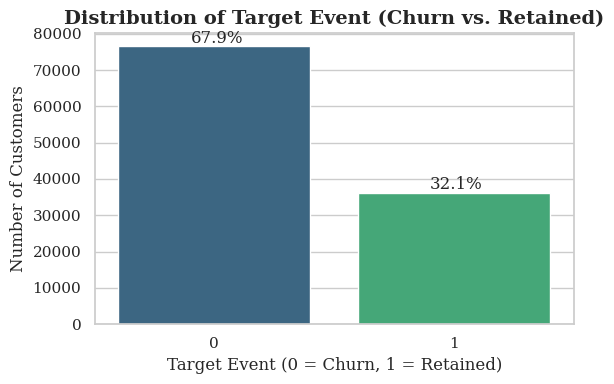

In [17]:
# Plotting the class distribution for the report
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, hue=target_col, palette="viridis", legend=False)
plt.title("Distribution of Target Event (Churn vs. Retained)", fontsize=14, fontweight="bold")
plt.xlabel("Target Event (0 = Churn, 1 = Retained)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Annotate bars with exact percentages to show class imbalance clearly
for p in ax.patches:
    percentage = f"{100 * p.get_height() / len(df):.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), size=12)

plt.tight_layout()
plt.show()

In [18]:
# --- DATA CLEANING & PREVENTION OF TARGET LEAKAGE ---

# 1. Remove identifier columns as they hold no predictive mathematical value
cols_to_drop = ["row_id", "user_id", "time_step"]

# 2. Remove other 'target_' columns to prevent data leakage. 
# If the model knows the future 'target_revenue', it will cheat to guess 'target_event'.
leakage_cols =["target_revenue", "target_customer_value", "target_customer_value_lag1", "target_actual_profit"]

# Combine the lists and drop them from the dataframe
df_clean = df.drop(columns=cols_to_drop + leakage_cols)

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape} (Removed IDs and Data Leaks)")

Original shape: (112610, 276)
Cleaned shape: (112610, 269) (Removed IDs and Data Leaks)


In [19]:
# Separate the dataset into Features (X) and Target (y)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Split the data: 70% for Training, 15% for Validation, 15% for Testing
# Stratify=y ensures the 0s and 1s are balanced across all splits
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

In [20]:
# Standardizes features by removing the mean and scaling to unit variance (z-score)
scaler = StandardScaler()

# Fit the scaler only on the training data to prevent information leakage from the test set
X_train_scaled = scaler.fit_transform(X_train)

# Apply the trained scaler to the validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape:   {X_train_scaled.shape}")
print(f"Validation Data Shape: {X_val_scaled.shape}")
print(f"Testing Data Shape:    {X_test_scaled.shape}")

Training Data Shape:   (78823, 268)
Validation Data Shape: (16895, 268)
Testing Data Shape:    (16892, 268)


In [21]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from keras.callbacks import EarlyStopping

In [22]:
# Set random seed for strictly reproducible results
tf.random.set_seed(42)

# Determine the number of input features (should be 268)
input_dim = X_train_scaled.shape[1]

print(input_dim)

268


In [23]:
def build_baseline_ann():
    model = Sequential([
        # Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer
        Dense(128, activation="relu"),
        
        # Dropout randomly turns off 30% of neurons to prevent overfitting
        Dropout(0.3), 
        
        # Second hidden layer
        Dense(64, activation="relu"),
        Dropout(0.2),
        
        # Third hidden layer
        Dense(32, activation="relu"),
        
        # Output layer: 1 neuron with Sigmoid activation for Binary Classification (0 to 1 probability)
        Dense(1, activation="sigmoid")
    ])
    
    # Compile the model with Adam optimizer and binary crossentropy loss
    # Crucially, we add Recall and AUC alongside basic accuracy
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])
    
    return model

In [24]:
def build_advanced_cnn():
    model = Sequential([
        # Input layer
        Input(shape=(input_dim, 1)),

        # Conv1D extracts localized spatial features across the 268 numerical columns
        # Note: input_shape requires (timesteps, features), so we use (input_dim, 1)
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2), # Compresses the data
        
        # Second Convolutional block
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        
        # Flatten transforms the 3D CNN output back to 1D for the Dense layers
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')])
    return model

In [25]:
# Initialize the models
ann_model = build_baseline_ann()
cnn_model = build_advanced_cnn()

# Print architecture summaries for the report
print("=== Baseline ANN Architecture ===")
ann_model.summary()

print("\n=== Advanced 1D-CNN Architecture ===")
cnn_model.summary()

=== Baseline ANN Architecture ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        34,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,801 (175.00 KB)

 Trainable params: 44,801 (175.00 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 266, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 133, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 131, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       133,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,681 (545.63 KB)

 Trainable params: 139,681 (545.63 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# CNNs require 3D input: (Batch_Size, Features, Channels)
# Reshape the 2D tabular data (Batch_Size, Features) into 3D by adding a '1' at the end
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))

early_stopping = EarlyStopping(
    monitor='val_loss',     # Watch the validation loss
    patience=5,             # Stop if it doesn't improve for 5 epochs
    restore_best_weights=True, # Automatically keep the best model
    verbose=1               # Print message when stopping
)

In [27]:
print("\n--- Training Baseline ANN ---")
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,          # Set high, but EarlyStopping will halt it earlier
    batch_size=256,     # Process 256 rows at a time
    callbacks=[early_stopping],
    verbose=2           # verbose=2 prints one summary line per epoch (Perfect for report samples!)
)

print("\n--- Training Advanced 1D-CNN ---")
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=2
)


--- Training Baseline ANN ---
Epoch 1/50
308/308 - 1s - 4ms/step - accuracy: 0.8163 - auc: 0.8452 - loss: 0.4295 - recall: 0.5750 - val_accuracy: 0.8447 - val_auc: 0.8799 - val_loss: 0.3787 - val_recall: 0.6597
Epoch 2/50
308/308 - 0s - 1ms/step - accuracy: 0.8389 - auc: 0.8735 - loss: 0.3872 - recall: 0.6319 - val_accuracy: 0.8474 - val_auc: 0.8847 - val_loss: 0.3704 - val_recall: 0.6696
Epoch 3/50
308/308 - 0s - 1ms/step - accuracy: 0.8440 - auc: 0.8801 - loss: 0.3772 - recall: 0.6472 - val_accuracy: 0.8506 - val_auc: 0.8886 - val_loss: 0.3642 - val_recall: 0.6772
Epoch 4/50
308/308 - 0s - 1ms/step - accuracy: 0.8470 - auc: 0.8847 - loss: 0.3707 - recall: 0.6549 - val_accuracy: 0.8514 - val_auc: 0.8909 - val_loss: 0.3612 - val_recall: 0.6820
Epoch 5/50
308/308 - 0s - 1ms/step - accuracy: 0.8481 - auc: 0.8873 - loss: 0.3666 - recall: 0.6589 - val_accuracy: 0.8514 - val_auc: 0.8915 - val_loss: 0.3597 - val_recall: 0.6777
Epoch 6/50
308/308 - 0s - 1ms/step - accuracy: 0.8507 - auc: 0.8

In [28]:
import keras_tuner as kt
from keras.optimizers import Adam
from keras.metrics import AUC, Recall

In [29]:
# 1. Define a "HyperModel" building function
def build_tunable_model(hp):
    model = Sequential()

    Input(shape=(input_dim, )),

    # Tune the number of units in the first Dense layer
    # Guess values between 64 and 256, in steps of 32
    hp_units_1 = hp.Int("units_1", min_value=64, max_value=256, step=32)
    model.add(Dense(units=hp_units_1, activation="relu"))

    # Tune the Dropout rate to find the perfect balance of regularization
    # Guess values between 0.1 and 0.5
    hp_dropout = hp.Float("dropout_1", min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout))

    # Second hidden layer (Static size for stability)
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(rate=hp_dropout))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    # Tune the learning rate of the optimizer
    # Trying 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss="binary_crossentropy",
                  metrics=["accuracy", Recall(name="recall"), AUC(name="auc")])
    
    return model

In [30]:
# 2. Initialize the Keras Tuner (RandomSearch)
# We optimize for 'val_auc' (Area Under the Curve) because of the class imbalance
tuner = kt.RandomSearch(
    build_tunable_model, 
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=5, # Limit to 5 attempts to save computational time
    executions_per_trial=1, # Trains 1 model per attempt
    directory="churn_tuning",
    project_name="ann_optimization",
    seed=42
)

In [31]:
# Print a summary of the tuning search space for the report
tuner.search_space_summary()

# 3. Execute the Hyperparameter Search
print("\n--- Starting Keras Tuner Search ---")
tuner.search(X_train_scaled, y_train, 
             epochs=15, 
             validation_data=(X_val_scaled, y_val),
             callbacks=[early_stopping], # Reuse our early stopping!
             verbose=1)

Trial 2 Complete [00h 00m 00s]

Best val_auc So Far: None
Total elapsed time: 00h 00m 00s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
160               |192               |units_1
0.1               |0.1               |dropout_1
0.001             |0.001             |learning_rate



Traceback (most recent call last):
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/tuner.py", line 421, in _configure_tensorboard_dir
    from tens

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/engine/tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/vincent-sequoia/miniconda3/envs/odl_project/lib/python3.13/site-packages/keras_tuner/src/e

In [ ]:
# 4. Extract the Best Model and Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n=== OPTIMAL HYPERPARAMETERS FOUND ===")
print(f"Optimal Units in Layer 1: {best_hps.get("units_1")}")
print(f"Optimal Dropout Rate:     {best_hps.get("dropout_1")}")
print(f"Optimal Learning Rate:    {best_hps.get("learning_rate")}")

# Build the final tuned model
final_tuned_model = tuner.hypermodel.build(best_hps)